In [1]:
import CommunityModelClass3 as cmc3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os

save_directory = "grid_search_diversity"
isExist = os.path.exists(save_directory)
if not isExist:
    os.makedirs(save_directory)

## Heatmap **Simpson Diversity** vs $w_0k_0$ and leakage:

In [2]:
# functions cell

def GridSearch(N_sim, k, leakage, inputs, path):

    results = np.zeros((N_sim,len(k),len(leakage)))

    for epoch in range(N_sim):

        for l in range(len(leakage)):   
            for i in range(len(k)):
                
                print("epoch:", epoch, "leakage:", l, "k_0:", i, end="\r")
                inputs["leakage"]=leakage[l]
                inputs["k_0"]=k[i]

                model=cmc3.CommunityModel(inputs)
                model.Simulate()
        
                data=model.ReturnSimpsonDiversity()    
                dd=np.mean(data)
                
                results[epoch][i][l]=dd     

    mean_matrix=np.mean(results,axis=0)

    mean_heat_map = pd.DataFrame(mean_matrix)
    mean_heat_map.to_csv(path,index=False,header=False)



def show_heatmap(heatmap_results):

    plt.imshow(heatmap_results, cmap="RdBu_r")
    plt.colorbar(shrink=0.8)
    plt.xlabel("Leakage")
    plt.ylabel("$w_0k_0/M$")

    for i in range(len(wk)):
        for j in range(len(leakage)):

            plt.annotate(np.round(heatmap_results[i, j],3), xy=(j, i), ha='center', va='center', color='black')
            
    plt.xticks(range(len(leakage)), leakage, rotation=30)
    plt.yticks(range(len(wk)), wk)
    plt.title("Mean Simpson Diversity")
    plt.show()


def show_heatmap_3d(total_mean_matrix,elev=45, azim=130):

    from mpl_toolkits import mplot3d

    rows, cols = np.shape(total_mean_matrix)

    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")

    x = np.arange(cols)
    y = np.arange(rows)
    X, Y = np.meshgrid(x, y)
    Z = total_mean_matrix

    ax.plot_surface(X, Y, Z, cmap="RdBu_r")

    ax.set_xlabel("Leakage")
    ax.set_ylabel("$w_0k_0$")
    ax.set_zlabel("Diversity")

    ax.set_xticks(range(len(leakage)), leakage)
    ax.set_yticks(range(len(wk)), wk)

    ax.view_init(elev=elev, azim=azim);


### Model params:

In [20]:
inputs={}

inputs["S_tot"] = 80
inputs["S"] = 40
inputs["R"] = 40

# initial conditions
inputs["S0"] = 10
inputs["R0"] = 5

# time simulation params
inputs["time_period"] = 1e5
inputs["t_step"] = 1

# partitions params
inputs["num_F"] = 4
inputs["num_T"] = 4
inputs["partition_F"] = [20]*4
inputs["partition_T"] = [10]*4

# activation function
inputs["sigma_type"] = "linear"
inputs["k"] = 20                           
inputs["N"] = 2

# h function params
inputs["tau_R"] = 1
inputs["k_alpha_index"] = 0

# metabolic matrix params
inputs["f_c"] = 0.25
inputs["f_s"] = 0.25
inputs["d0"] = 0.2

# preference matrix params
inputs["preference_type"] = "binary"
inputs["mu_c"] = 4.5
inputs["sigma_c"] = 0.3
inputs["c_0"] = 1
inputs["c_1"] = 1
inputs["q_A"] = 0.5


# save params:
df_inputs=pd.DataFrame(inputs)
df_inputs.to_csv(save_directory+"/params_GS_diversity.csv")

### Grid search:

In [3]:
folder = save_directory + "/"

leakage=np.round(np.linspace(0.001,0.9,num=5),3)
wk=np.logspace(0, 3, num=5, base=10)
wk=np.round(wk,0)
wk = wk[::-1]

In [22]:
N_sim = 10

output_name = "diversity_heatmap_bin_10.csv"
path = folder + output_name

#GridSearch(N_sim, wk, leakage, inputs, path)

### Mean heatmap (100 runs):

In [4]:
a1 = np.genfromtxt(folder + "diversity_heatmap_bin_1.csv", delimiter=",")
a2 = np.genfromtxt(folder + "diversity_heatmap_bin_2.csv", delimiter=",")
a3 = np.genfromtxt(folder + "diversity_heatmap_bin_3.csv", delimiter=",")
a4 = np.genfromtxt(folder + "diversity_heatmap_bin_4.csv", delimiter=",")
a5 = np.genfromtxt(folder + "diversity_heatmap_bin_5.csv", delimiter=",")
a6 = np.genfromtxt(folder + "diversity_heatmap_bin_6.csv", delimiter=",")
a7 = np.genfromtxt(folder + "diversity_heatmap_bin_7.csv", delimiter=",")
a8 = np.genfromtxt(folder + "diversity_heatmap_bin_8.csv", delimiter=",")
a9 = np.genfromtxt(folder + "diversity_heatmap_bin_9.csv", delimiter=",")
a10 = np.genfromtxt(folder + "diversity_heatmap_bin_10.csv", delimiter=",")


total_mean_matrix = np.mean(np.array([a1,a2,a3,a4,a5,a6,a7,a8,a9,a10]),axis=0)

In [5]:
final_output_name = "mean_diversity_1_resources.csv"
path = folder + final_output_name

total_mean_matrix = pd.DataFrame(total_mean_matrix)
total_mean_matrix.to_csv(path,index=False,header=False)

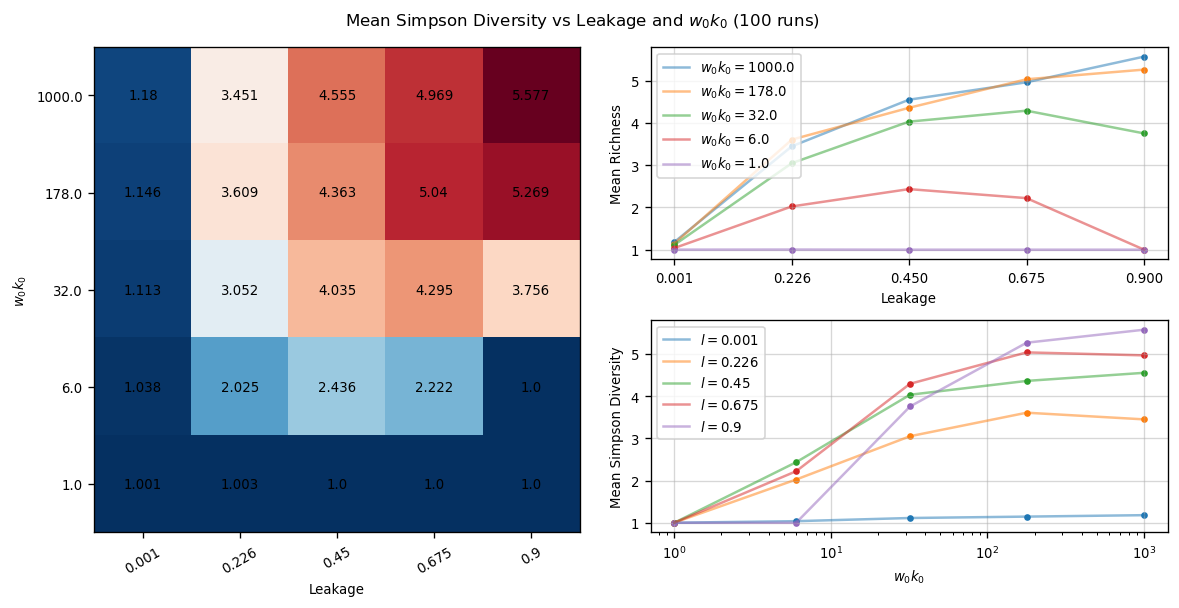

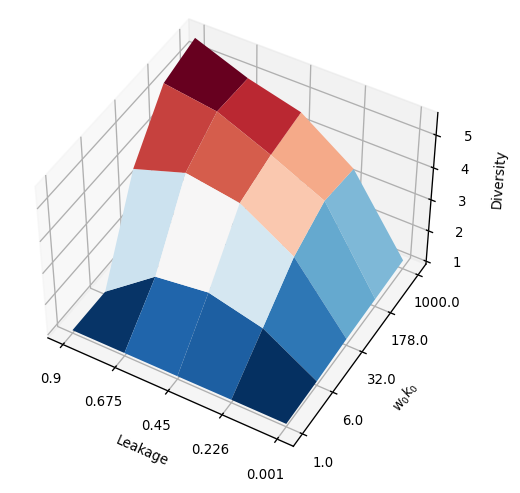

In [24]:
fig = plt.figure(tight_layout=True, figsize=(10,5))
gs = gridspec.GridSpec(2, 2, height_ratios=(1,1))
fig.suptitle("Mean Simpson Diversity vs Leakage and $w_0k_0$ (100 runs)",fontsize=10)

ax = fig.add_subplot(gs[:, 0])
ax.imshow(total_mean_matrix, cmap="RdBu_r")
ax.set_xlabel("Leakage")
ax.set_ylabel("$w_0k_0$")

for i in range(len(wk)):
    for j in range(len(leakage)):
       ax.annotate(np.round(total_mean_matrix[i, j],3), xy=(j, i), ha='center', va='center', color='black') 
ax.set_xticks(range(len(leakage)), leakage, rotation=30)
ax.set_yticks(range(len(wk)), wk)

ax = fig.add_subplot(gs[0, 1])
ax.grid(alpha=0.5)
for i,j in zip(range(len(wk)),wk):
    ax.scatter(leakage,total_mean_matrix[i],marker=".")
    ax.plot(leakage,total_mean_matrix[i],label="$w_0k_0=${}".format(j),alpha=0.5)
    ax.set_xticks(leakage)
    ax.set_xlabel("Leakage")
    ax.set_ylabel("Mean Richness")
    ax.legend(loc=2)

ax = fig.add_subplot(gs[1, 1])
ax.grid(alpha=0.5)
for i,j in zip(range(total_mean_matrix.shape[0]),leakage):
    ax.scatter(wk,total_mean_matrix[:,i],marker=".")
    ax.plot(wk,total_mean_matrix[:,i],label="$l=${}".format(j),alpha=0.5)
    ax.set_xlabel("$w_0k_0$")
    ax.set_ylabel("Mean Simpson Diversity")
    ax.set_xscale("log")
    ax.legend(loc=2)

#--------------------------------------------

show_heatmap_3d(total_mean_matrix,elev=45, azim=120)